## Hw 9
## Student name:     

## Problem 1: Image Classification with the CIFAR-10 Dataset (40 points)

You have been given a dataset of 60,000 32x32 color images in 10 classes, known as the CIFAR-10 dataset. The CIFAR-10 dataset is a collection of 60,000 32x32 color images in 10 classes, each with 6,000 images. The classes include:
1. airplane
2. automobile
3. bird
4. cat
5. deer
6. dog
7. frog
8. horse
9. ship
10. truck

The dataset is divided into 50,000 training images and 10,000 testing images. The images are in RGB format with 3 channels (red, green, and blue) and 8 bits per channel.

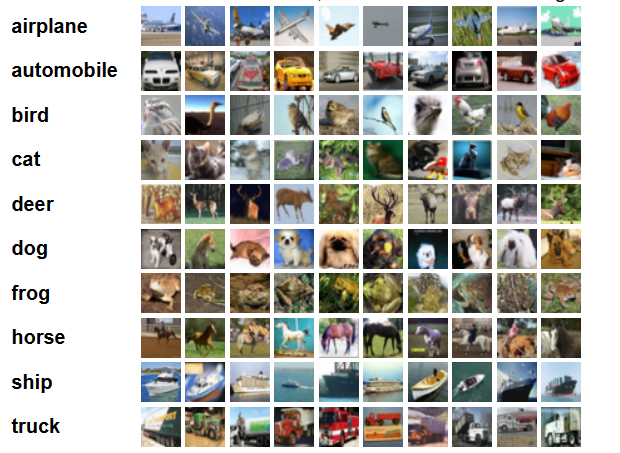

### Image Classification Model Development
Below is a code for an image classification model aiming to classify images into their respective classes:

```python

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels)  = cifar10.load_data()

# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images  = test_images / 255.0
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)

# Define the model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10),
])

#    layers.Dense(10, activation='softmax'),
# Compile the model (uisng adaptive moment estimation optimization algorithm)
model.compile(optimizer='adam', # Adam (Adaptive Moment Estimation) 
              loss='categorical_crossentropy', #Used for multi-class classification with one-hot encoded labels.
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc)
```
    
    
### Question 1    
Upon evaluating the model on the validation data, an accuracy of less than 10% was observed and that because I made a mistake upon creating my mode, please correct for that.

### Question 2
The current datasets are RGB color images. Rewrite the above code to convert the images in the datasets into grayscale (use the `tf.image.rgb_to_grayscale` function), rebuild the model for classification, and evaluate the model. Plot 3 randomly selected images and their predicted and true classes using the trained model, using vertical subplots.

### Question 3
Download three example images from online sources, process them, and use them as input to the previously created models (RGB and grayscale). Test the neural network with these images. Create a single plot using subplots to display the images, and add titles to indicate the labels predicted by the model for each image.

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels)  = cifar10.load_data()

# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images  = test_images / 255.0
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)

# Define the model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation = 'softmax'),
])

#    layers.Dense(10, activation='softmax'),
# Compile the model (uisng adaptive moment estimation optimization algorithm)
model.compile(optimizer='adam', # Adam (Adaptive Moment Estimation) 
              loss='categorical_crossentropy', #Used for multi-class classification with one-hot encoded labels.
              metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.4936 - loss: 1.4172 - val_accuracy: 0.5835 - val_loss: 1.1718
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6262 - loss: 1.0671 - val_accuracy: 0.6342 - val_loss: 1.0312
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.6727 - loss: 0.9348 - val_accuracy: 0.6388 - val_loss: 1.0286
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7059 - loss: 0.8406 - val_accuracy: 0.6755 - val_loss: 0.9452
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7344 - loss: 0.7610 - val_accuracy: 0.6848 - val_loss: 0.9475
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7561 - loss: 0.7003 - val_accuracy: 0.6896 - val_loss: 0.9268
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7774 - loss: 0.6335 - val_accuracy: 0.6969 - val_loss: 0.9100
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7987 -

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels)  = cifar10.load_data()

train_images = tf.image.rgb_to_grayscale(train_images).numpy()
test_images  = tf.image.rgb_to_grayscale(test_images).numpy()

# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images  = test_images / 255.0
train_labels = to_categorical(train_labels)
test_labels  = to_categorical(test_labels)

# Define the model
model_gray = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation = 'softmax'),
])

#    layers.Dense(10, activation='softmax'),
# Compile the model (uisng adaptive moment estimation optimization algorithm)
model_gray.compile(optimizer='adam', # Adam (Adaptive Moment Estimation) 
              loss='categorical_crossentropy', #Used for multi-class classification with one-hot encoded labels.
              metrics=['accuracy'])

# Train the model
model_gray.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

# Evaluate the model
test_loss, test_acc = model_gray.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.4410 - loss: 1.5813 - val_accuracy: 0.5346 - val_loss: 1.3349
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.5796 - loss: 1.2111 - val_accuracy: 0.6029 - val_loss: 1.1470
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6323 - loss: 1.0664 - val_accuracy: 0.6254 - val_loss: 1.0780
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6637 - loss: 0.9672 - val_accuracy: 0.6541 - val_loss: 0.9966
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6953 - loss: 0.8830 - val_accuracy: 0.6441 - val_loss: 1.0402
313/313 - 3s - 10ms/step - accuracy: 0.6441 - loss: 1.0402
Test accuracy: 0.64410001039505


tf.Tensor(
[[5.9278270e-11 4.5251511e-12 3.0618551e-07 1.3103217e-05 2.4894507e-05
  9.1416505e-06 1.2004193e-07 9.9995244e-01 1.7271725e-12 2.0948385e-09]], shape=(1, 10), dtype=float32)
tf.Tensor(
[[1.51182925e-02 8.10131096e-05 1.36454208e-02 1.10927923e-02
  1.17876297e-02 1.01213725e-02 9.65598796e-04 9.29356933e-01
  4.63193755e-05 7.78472004e-03]], shape=(1, 10), dtype=float32)
horse
horse


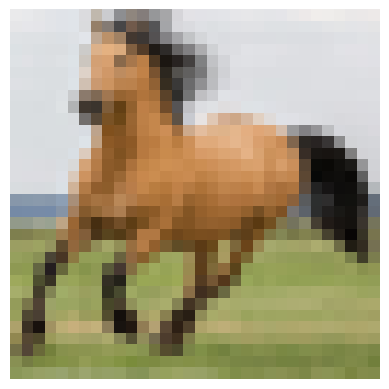

In [20]:
from PIL import Image

img = Image.open('horse.jpg').convert('RGB')
img = img.resize((32,32))
img = np.array(img)
rgb1 = img/255.0
gray1 = tf.image.rgb_to_grayscale(rgb1 ).numpy()


pred_rgb_1 = model(rgb1.reshape(1,32,32,3))
pred_gray_1 = model_gray(gray1.reshape(1,32,32,1))

print(pred_rgb_1)
print(pred_gray_1)

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

print(class_names[np.argmax(pred_rgb_1)])
print(class_names[np.argmax(pred_gray_1)])

plt.imshow(rgb1)
plt.axis("off")
plt.show()

In [18]:
ls


 Volume in drive C has no label.
 Volume Serial Number is 3E83-AEF0

 Directory of C:\Users\Bahaa\OneDrive\Desktop\umd\2025\BIOE 658 Fall 2024 python\NewAIML\hw9

12/08/2025  05:41 PM    <DIR>          .
12/01/2025  05:12 PM    <DIR>          ..
12/08/2025  04:54 PM    <DIR>          .ipynb_checkpoints
12/08/2025  04:31 PM            18,983 airplane.jpg
12/08/2025  04:45 PM             6,792 classification.py
12/08/2025  04:32 PM            15,869 dog.jpg
12/08/2025  04:11 PM             3,818 Gaussian denoising.py
12/01/2025  08:31 AM            63,634 gaussian_spectra.txt
12/08/2025  04:29 PM            42,431 horse.jpg
12/05/2025  05:46 PM           562,522 hw9.ipynb
12/08/2025  05:41 PM           835,412 hw9-solved.ipynb
12/08/2025  04:53 PM             1,116 Pb2.py
12/08/2025  04:49 PM             1,392 Pb3.py
              10 File(s)      1,551,969 bytes
               3 Dir(s)  365,908,299,776 bytes free


# Probelm 2 (10 points): 
Find the roots of the following function and Use $x \in [-5, 5]$ as the search interval.:

$$
f(x) = e^{-x^2} \sin(5x) - \frac{x}{10}
$$

Use the bisection method with a tolerance of $10^{-6}$ for root accuracy and plot the function $f(x)$ over the interval $[-5, 5]$ to define the subintervals. Finally, use visual markers to highlight all roots discovered by your program.

**Please only use methods and functions covered by the course materials. Utilizing other methods may lead to score degradation.**



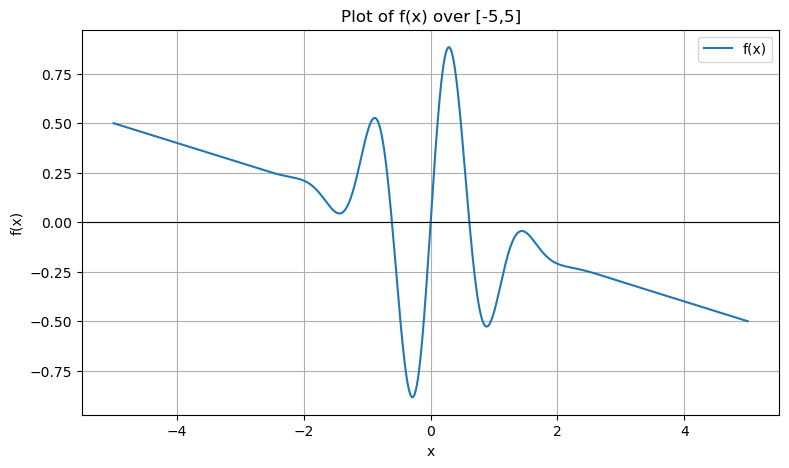

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
    return np.exp(-x**2) * np.sin(5*x) - x/10

# Make x-grid for plotting
x = np.linspace(-5, 5, 2000)
y = f(x)

# Plot
plt.figure(figsize=(9,5))
plt.plot(x, y, label='f(x)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x) over [-5,5]')
plt.grid(True)
plt.legend()
plt.show()

In [74]:
def secant(x0, x1, func, tol=1e-6, max_iter=50):
    for i in range(max_iter):
        f0 = func(x0)
        f1 = func(x1)
        
        if abs(f1 - f0) < 1e-12:
            print("Secant method failed: division by zero.")
            return None
        
        # Secant formula
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        
        if abs(func(x2)) < tol:
            return x2
        
        x0, x1 = x1, x2
    
    return x2

r1 = secant(-0.7,-0.6,f)
r2 = secant(-0.2,0.12,f)
r3 = secant(0.46,0.68,f)

print(r1,r2,r3)

-0.6105670066222961 1.3735387811977759e-12 0.6105670238134405


# Problem 3 (20 points): 

You are an engineer working on a **renewable energy project** involving a solar power plant. The power output $ P(t) $ of the plant (in kilowatts) is measured at specific times $ t $ throughout the day, but the data points are sparse. Your task is to:

Determine the time(s) $ t $ when the power output reaches a specific threshold $ P_{\text{threshold}} = $ 500 kW.


The power output is measured at the following times $ t $ (in hours) and power values $ P(t)$ (in kW):

| $ t$ (hours) | $ P(t)$ (kW) |
|-----------------|-----------------|
| 6              | 100             |
| 9              | 400             |
| 12             | 800             |
| 15             | 600             |
| 18             | 200             |


***Use only functions and methods we covered in the class and course materials. Utilizing other methods may lead to score degradation***


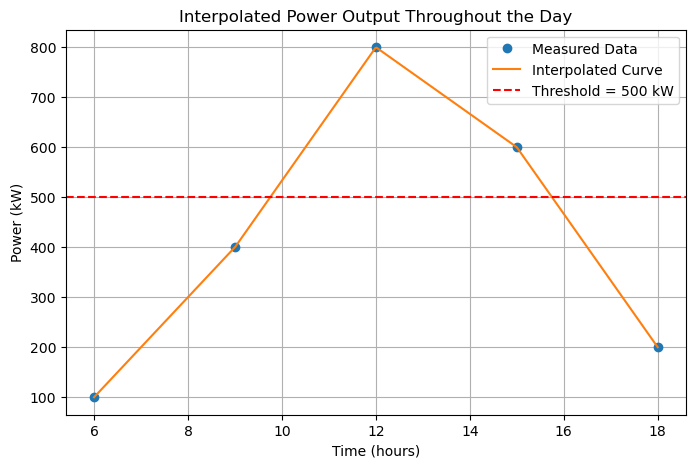

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Given data
t = np.array([6, 9, 12, 15, 18])
P = np.array([100, 400, 800, 600, 200])

# Interpolation function
f = interp1d(t, P, kind='linear')

# Create a smooth grid for plotting
tt = np.linspace(6, 18, 400)
PP = f(tt)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, P, 'o', label='Measured Data')
plt.plot(tt, PP, '-', label='Interpolated Curve')
plt.axhline(500, color='r', linestyle='--', label='Threshold = 500 kW')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.grid(True)
plt.legend()
plt.title("Interpolated Power Output Throughout the Day")
plt.show()

In [76]:
def secant(x0, x1, func, tol=1e-6, max_iter=50):
    for i in range(max_iter):
        f0 = func(x0)
        f1 = func(x1)
        
        if abs(f1 - f0) < 1e-12:
            print("Secant method failed: division by zero.")
            return None
        
        # Secant formula
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        
        if abs(func(x2)) < tol:
            return x2
        
        x0, x1 = x1, x2
    
    return x2

def g(t):
    return f(t) - 500

# First crossing between 9 and 12
t1 = secant(9, 12, g)

# Second crossing between 15 and 18
t2 = secant(15, 18, g)

print("Power = 500 kW at t =", t1)
print("Power = 500 kW at t =", t2)

Power = 500 kW at t = 9.75
Power = 500 kW at t = 15.75


# Problem 4: Gaussian Spectra Denoising (30 points)

In this assignment, you are provided with a dataset containing **five different Gaussian spectra** with added noise. Each spectrum has **500 data points**, stored as columns in a text file. Your task is to denoise these spectra using a neural network model.

### Dataset Description
- The dataset contains five columns, each representing one noisy Gaussian spectrum.
- Each column corresponds to 500 data points.
- The spectra are Gaussian-like curves, each with a peak of 1 and random variations in width and peak location.

### Your Tasks
1. **Visualize the Spectra**:
   - Load the data from the provided text file 'gaussian_spectra.txt'.
   - Plot each noisy spectrum to understand its structure.

2. **Build a Neural Network**:
   - Design a neural network model that can learn to denoise these spectra.
   - You may refer to previous examples discussed in class (e.g., denoising sine waves).

3. **Denoise the Spectra**:
   - Train the neural network using the noisy spectra provided in the dataset.
   - Test the model on the five noisy spectra provided in the dataset..

4. **Plot the Results**:
   - Plot the noisy spectra alongside their denoised counterparts.
   - Compare the outputs visually to evaluate the model's performance.


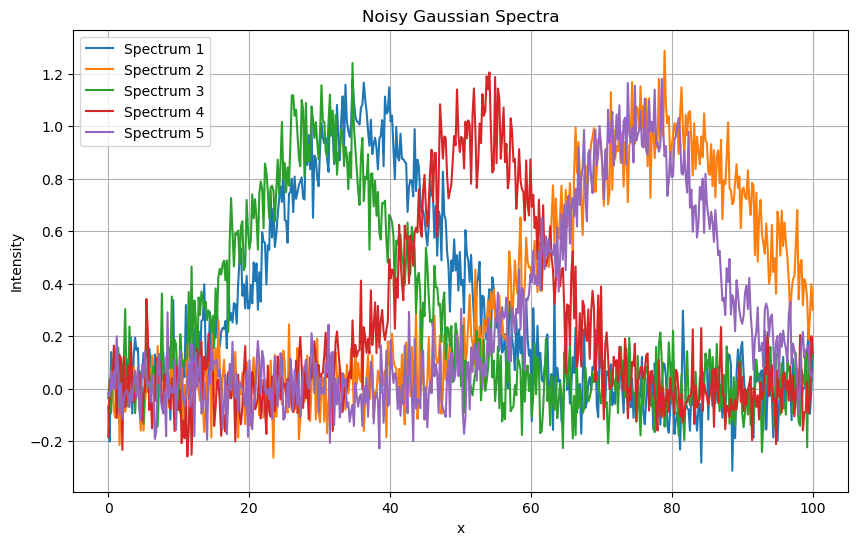

In [42]:
import numpy as np
import matplotlib.pyplot as plt
# Load the data
file_path = "gaussian_spectra.txt"
loaded_spectra = np.loadtxt(file_path)

# Plot the spectra
x = np.linspace(0, 100, loaded_spectra.shape[0])  # Recreate the x-axis
plt.figure(figsize=(10, 6))

for i in range(loaded_spectra.shape[1]):
    plt.plot(x, loaded_spectra[:, i], label=f"Spectrum {i+1}")

plt.title("Noisy Gaussian Spectra")
plt.xlabel("x")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
print(loaded_spectra.shape)

(500, 5)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

'C:\\Users\\Bahaa\\OneDrive\\Desktop\\umd\\2025\\BIOE 658 Fall 2024 python\\NewAIML\\hw9'

In [56]:
import numpy as np
import matplotlib.pyplot as plt


def generate_guassian_spectra(num_signals,n_samples=500,fwhm_range = (15,60),noise_std = 0.1, x_min= 0, x_max = 100):
    x = np.linspace(x_min,x_max,n_samples)
    clean_list = []
    clean_noisy = []

    for i in range(num_signals):
        center = np.random.uniform(x_min,x_max)
        fwhm = np.random.uniform(fwhm_range[0],fwhm_range[1])
        sigma = fwhm/(2*np.sqrt(2*np.log(2)))
        clean_signal = np.exp(-0.5*((x-center)/sigma)**2)
        noise = np.random.normal(0,noise_std,n_samples)
        noisy_signal = clean_signal + noise

        clean_list.append(clean_signal)
        clean_noisy.append(noisy_signal)
    clean = np.array(clean_list)
    noisy = np.array(clean_noisy)
    
    return x, clean, noisy

In [63]:
num_signals = 1000
n_samples = 500
noise_std = 0.1

x, signals, noisy_signals = generate_guassian_spectra(num_signals,n_samples,(15,60),noise_std , 0, 100)

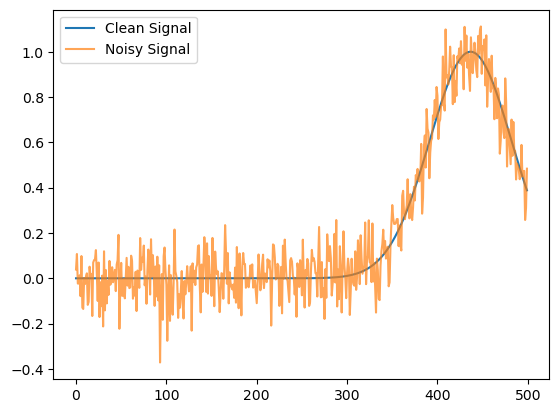

In [64]:
plt.figure()
plt.plot(signals[0,:], label='Clean Signal')
plt.plot(noisy_signals[0,:],label='Noisy Signal', alpha=0.7)
plt.legend()

In [65]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

model = Sequential([
    Conv1D(64,5,padding='same',activation='relu', input_shape = (n_samples,1)),
    Conv1D(32,5,padding='same',activation='relu'),
    Flatten(),
    Dense(n_samples),#,activation='linear'),
    ])

model.compile(optimizer='adam',loss='mse')

In [66]:
# Your code here
train_split = int(0.8 * num_signals)
x_train = noisy_signals[:train_split]
y_train = signals[:train_split]
x_val = noisy_signals[train_split:]
y_val = signals[train_split:]

In [70]:
model.fit(x_train,y_train,epochs = 2, validation_data = (x_val,y_val))

Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 2.4981e-04 - val_loss: 3.0359e-04
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 2.1300e-04 - val_loss: 3.0536e-04


(500, 5)
(5, 500)
(5, 500, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


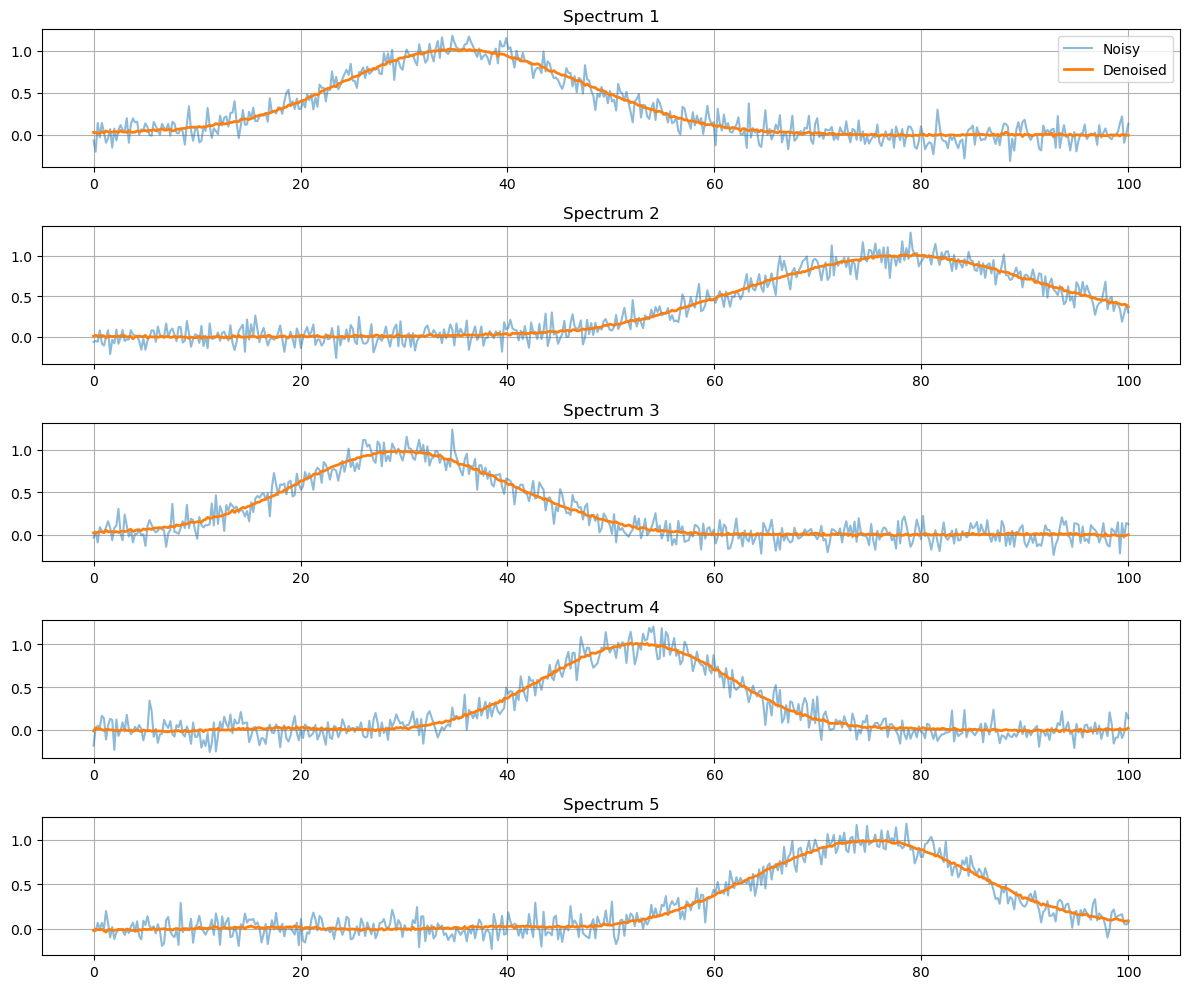

In [71]:
import numpy as np
import matplotlib.pyplot as plt
# Load the data
file_path = "gaussian_spectra.txt"
real_noisy = np.loadtxt(file_path)

print(real_noisy.shape)
real_noisy = real_noisy.T
print(real_noisy.shape)
real_noisy = real_noisy.reshape(5,500,1)

print(real_noisy.shape)

real_denoised = model.predict(real_noisy)


x = np.linspace(0, 100, 500)

plt.figure(figsize=(12,10))

for i in range(5):
    plt.subplot(5,1,i+1)
    plt.plot(x, real_noisy[i], label="Noisy", alpha=0.5)
    plt.plot(x, real_denoised[i], label="Denoised", linewidth=2)
    plt.title(f"Spectrum {i+1}")
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()
